# Exploratory analysis: training data

Profiles the data behind the withdrawal-risk model, loaded exactly as the
pipeline sees it (`train.load_data()` — the LBNL *Queued Up* through-2025
workbook, with edition column names normalized and only the four modeled
statuses kept).

Contents:
1. Columns, datatypes, and null percentages.
2. Resolution rate and withdrawal rate by queue entry year.

The model itself trains on the *resolved* subset of *mature* cohorts (queue
years 2000–2018); the by-year charts below show why that window is chosen.

In [1]:
import sys
sys.path.insert(0, '../model')  # import the pipeline's own loader
import train

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# train.py forces the non-interactive Agg backend on import; re-enable the
# inline backend so figures embed in this notebook.
%matplotlib inline

pd.set_option('display.max_rows', 40)

queue = train.load_data()
print('Source file :', train.DATA_FILE.name)
print('Shape       :', f'{queue.shape[0]:,} rows x {queue.shape[1]} columns')
print('Statuses    :', queue['q_status'].value_counts().to_dict())
print('Train window:', f'resolved + q_year {train.TRAIN_YEAR_MIN}-{train.TRAIN_YEAR_MAX}')


Source file : LBNL_Ix_Queue_Data_File_thru2025.xlsx
Shape       : 38,191 rows x 30 columns
Statuses    : {'withdrawn': 24221, 'active': 8513, 'operational': 4789, 'suspended': 668}
Train window: resolved + q_year 2000-2018


## 1. Columns, datatypes, and null percentages
One row per column, sorted by null percentage (most-missing first). `n_unique` is included as a quick cardinality check.

In [2]:
schema = pd.DataFrame({
    'dtype': queue.dtypes.astype(str),
    'non_null': queue.notna().sum(),
    'null_pct': (queue.isna().mean() * 100).round(1),
    'n_unique': queue.nunique(dropna=True),
})
schema.index.name = 'column'
schema = schema.sort_values('null_pct', ascending=False)
print(f'{len(schema)} columns total\n')
display(schema)


30 columns total



,dtype,non_null,null_pct,n_unique
column,,,,
mw3,float64,45,99.9,25
type_3,object,110,99.7,4
mw2,float64,1096,97.1,431
on_date,datetime64[ns],3709,90.3,1891
ia_date,datetime64[ns],4833,87.3,2741
type_2,object,5057,86.8,10
developer,object,8487,77.8,4518
cluster,object,12392,67.6,644
project_name,object,13088,65.7,11555


## 2. Resolution rate and withdrawal rate by year

For each queue entry year:

- **Resolution rate** = resolved / total, where *resolved* = withdrawn +
  operational. Low values mean the cohort is still largely pending (censored).
- **Withdrawal rate (among resolved)** = withdrawn / resolved — of the projects
  that have reached an outcome, the share that were withdrawn.
- **Withdrawal share of cohort** = withdrawn / total, shown for reference.

In [3]:
byyear = queue.dropna(subset=['q_year']).copy()
byyear['q_year'] = byyear['q_year'].astype(int)
byyear = byyear[byyear['q_year'].between(2000, byyear['q_year'].max())]

ct = pd.crosstab(byyear['q_year'], byyear['q_status'])
for col in ['withdrawn', 'operational', 'active', 'suspended']:
    if col not in ct:
        ct[col] = 0

rates = pd.DataFrame(index=ct.index)
rates['n'] = ct.sum(axis=1)
rates['resolved'] = ct['withdrawn'] + ct['operational']
rates['withdrawn'] = ct['withdrawn']
rates['operational'] = ct['operational']
rates['resolution_rate'] = rates['resolved'] / rates['n']
rates['withdrawal_rate_among_resolved'] = (
    rates['withdrawn'] / rates['resolved'].replace(0, np.nan)
)
rates['withdrawal_share_of_cohort'] = rates['withdrawn'] / rates['n']
display(rates.round(3))


,n,resolved,withdrawn,operational,resolution_rate,withdrawal_rate_among_resolved,withdrawal_share_of_cohort
q_year,,,,,,,
2000,304,302,221,81,0.993,0.732,0.727
2001,528,522,410,112,0.989,0.785,0.777
2002,276,275,190,85,0.996,0.691,0.688
2003,326,323,201,122,0.991,0.622,0.617
2004,318,310,200,110,0.975,0.645,0.629
2005,516,508,318,190,0.984,0.626,0.616
2006,760,747,538,209,0.983,0.720,0.708
2007,1125,1099,799,300,0.977,0.727,0.710
2008,1228,1217,1052,165,0.991,0.864,0.857


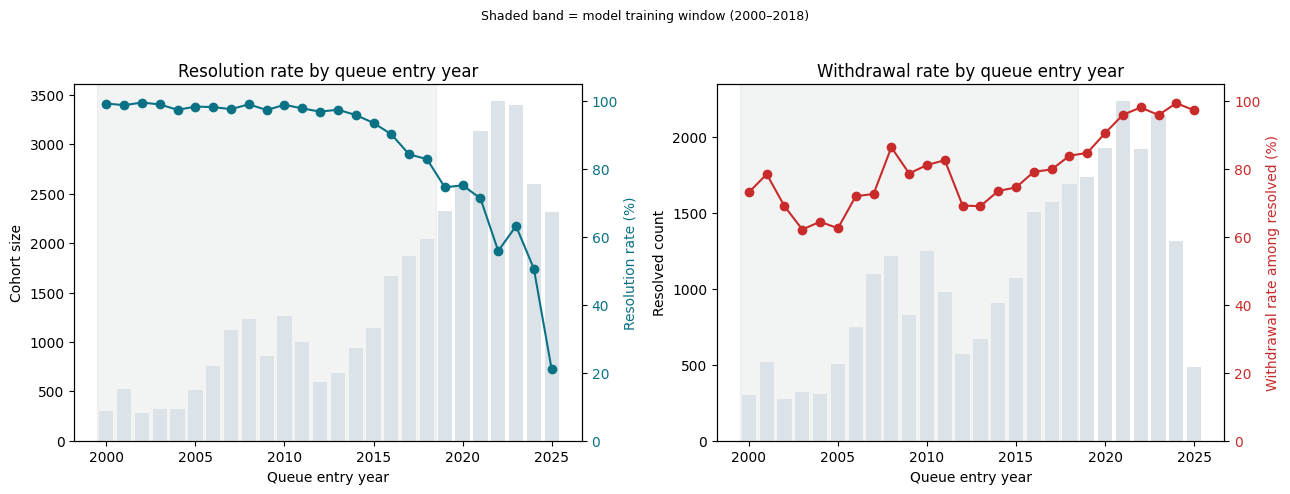

In [4]:
years = rates.index.to_numpy()
lo, hi = train.TRAIN_YEAR_MIN, train.TRAIN_YEAR_MAX
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)

# Panel A: resolution rate (line) over cohort size (bars).
ax = axes[0]
ax.bar(years, rates['n'], color='#dce3e8', label='cohort size (n)')
ax.set_ylabel('Cohort size'); ax.set_xlabel('Queue entry year')
ax.axvspan(lo - 0.5, hi + 0.5, color='#102a36', alpha=0.05, zorder=0)
axr = ax.twinx()
axr.plot(years, rates['resolution_rate'] * 100, 'o-', color='#0b7285',
         label='resolution rate')
axr.set_ylabel('Resolution rate (%)', color='#0b7285'); axr.set_ylim(0, 105)
axr.tick_params(axis='y', labelcolor='#0b7285')
ax.set_title('Resolution rate by queue entry year')

# Panel B: withdrawal rate among resolved (line) over resolved count (bars).
ax = axes[1]
ax.bar(years, rates['resolved'], color='#dce3e8', label='resolved count')
ax.set_ylabel('Resolved count'); ax.set_xlabel('Queue entry year')
ax.axvspan(lo - 0.5, hi + 0.5, color='#102a36', alpha=0.05, zorder=0)
axr = ax.twinx()
axr.plot(years, rates['withdrawal_rate_among_resolved'] * 100, 'o-',
         color='#c92a2a', label='withdrawal rate (among resolved)')
axr.set_ylabel('Withdrawal rate among resolved (%)', color='#c92a2a')
axr.set_ylim(0, 105); axr.tick_params(axis='y', labelcolor='#c92a2a')
ax.set_title('Withdrawal rate by queue entry year')

fig.suptitle('Shaded band = model training window '
             f'({lo}\u2013{hi})', fontsize=9, y=1.02)
fig.tight_layout(); plt.show()


### Takeaway
The **resolution rate** sits near 100% for older cohorts and falls off sharply
for recent years — those projects simply have not had time to resolve, which is
the censoring the training window guards against. Among the projects that *have*
resolved, the **withdrawal rate** is high throughout and climbs toward ~99% for
the most recent cohorts (their few resolved projects are almost all early
withdrawals). Training on the resolved subset of mature cohorts (2000–2018,
shaded) keeps the labels representative rather than dominated by this artifact.

## 3. Interconnection agreement columns in detail

The IA milestone drives the model's strongest feature, `ia_executed`. Three raw
columns describe it: `IA_status_clean` (normalized phase), `ia_date` (execution
date), and `IA_phase_raw` (the high-cardinality source text). Below are the
value distributions plus resolution and withdrawal rates for each group,
**keeping nulls as their own category** — important because `IA_status_clean` is
~19% null and `ia_date` is ~87% null, and those null groups are not benign.

In [5]:
ia_cols = ['IA_status_clean', 'ia_date', 'IA_phase_raw']
print('IA column null %:')
print((queue[ia_cols].isna().mean() * 100).round(1).to_string())

print('\nIA_status_clean — value counts (nulls kept):')
print(queue['IA_status_clean'].value_counts(dropna=False).to_string())

print(f"\nIA_phase_raw — top 10 of {queue['IA_phase_raw'].nunique():,} raw values:")
print(queue['IA_phase_raw'].value_counts(dropna=False).head(10).to_string())

# Resolution / withdrawal rates per group, KEEPING nulls as their own category
# (groupby dropna=False). 'resolved' = withdrawn or operational.
ia = queue.copy()
ia['resolved'] = ia['q_status'].isin(['withdrawn', 'operational'])
ia['withdrawn'] = (ia['q_status'] == 'withdrawn').astype(int)
ia['ia_executed'] = (
    ia['IA_status_clean'].isin(train.IA_EXECUTED_STATUSES) | ia['ia_date'].notna()
).astype(int)
ia['ia_date_present'] = ia['ia_date'].notna()

def ia_rates(column):
    g = ia.groupby(column, dropna=False)
    out = pd.DataFrame({'n': g.size(),
                        'resolved': g['resolved'].sum(),
                        'withdrawn': g['withdrawn'].sum()})
    out['resolution_rate'] = out['resolved'] / out['n']
    out['withdrawal_rate_among_resolved'] = (
        out['withdrawn'] / out['resolved'].replace(0, np.nan)
    )
    out['withdrawal_share_of_total'] = out['withdrawn'] / out['n']
    return out.sort_values('n', ascending=False)

print('\nResolution / withdrawal rates by IA_status_clean (nulls kept):')
display(ia_rates('IA_status_clean').round(3))
print('By ia_executed flag (the model feature):')
display(ia_rates('ia_executed').round(3))
print('By ia_date present vs absent:')
display(ia_rates('ia_date_present').round(3))


IA column null %:
column
IA_status_clean    18.8
ia_date            87.3
IA_phase_raw       38.6

IA_status_clean — value counts (nulls kept):
IA_status_clean
IA Executed                    9597
NaN                            7161
Withdrawn                      5297
System Impact Study            4042
Feasibility Study              3699
Facility Study                 3017
In Progress (unknown study)    2474
Cluster Study                  1691
IA Pending                      594
Not Started                     306
Construction                    198
Suspended                       115

IA_phase_raw — top 10 of 1,183 raw values:
IA_phase_raw
NaN                                                                                                                                        14731
Withdrawn                                                                                                                                   2295
WITHDRAWN                                                     

,n,resolved,withdrawn,resolution_rate,withdrawal_rate_among_resolved,withdrawal_share_of_total
IA_status_clean,,,,,,
IA Executed,9597,7308,2519,0.761,0.345,0.262
NaN,7161,6048,6048,0.845,1.000,0.845
Withdrawn,5297,5297,5297,1.000,1.000,1.000
System Impact Study,4042,3248,3248,0.804,1.000,0.804
Feasibility Study,3699,3170,3170,0.857,1.000,0.857
Facility Study,3017,1241,1241,0.411,1.000,0.411
In Progress (unknown study),2474,1373,1373,0.555,1.000,0.555
Cluster Study,1691,725,725,0.429,1.000,0.429
IA Pending,594,385,385,0.648,1.000,0.648


By ia_executed flag (the model feature):


,n,resolved,withdrawn,resolution_rate,withdrawal_rate_among_resolved,withdrawal_share_of_total
ia_executed,,,,,,
0,27776,21317,21317,0.767,1.000,0.767
1,10415,7693,2904,0.739,0.377,0.279


By ia_date present vs absent:


,n,resolved,withdrawn,resolution_rate,withdrawal_rate_among_resolved,withdrawal_share_of_total
ia_date_present,,,,,,
False,33358,25635,22863,0.768,0.892,0.685
True,4833,3375,1358,0.698,0.402,0.281


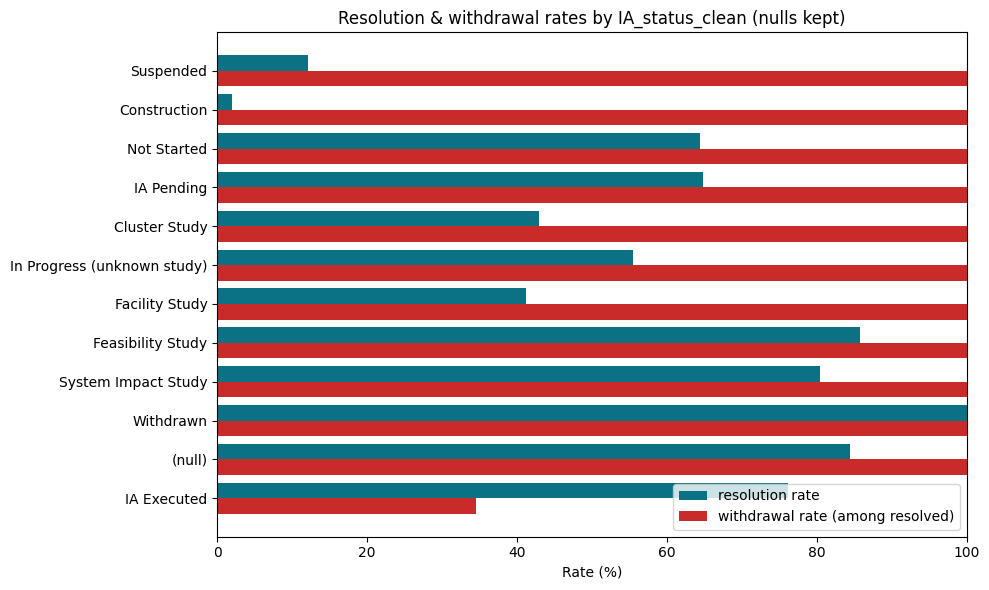

In [6]:
# Visualize both rates per IA_status_clean group, nulls included, ordered by
# withdrawal rate so 'IA Executed' (the only group that ever completes) stands out.
t = ia_rates('IA_status_clean').sort_values('withdrawal_rate_among_resolved')
labels = ['(null)' if pd.isna(i) else str(i) for i in t.index]
y = np.arange(len(t))
h = 0.4
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(y + h / 2, t['resolution_rate'] * 100, height=h,
        color='#0b7285', label='resolution rate')
ax.barh(y - h / 2, t['withdrawal_rate_among_resolved'] * 100, height=h,
        color='#c92a2a', label='withdrawal rate (among resolved)')
ax.set_yticks(y); ax.set_yticklabels(labels)
ax.set_xlim(0, 100); ax.set_xlabel('Rate (%)')
ax.set_title('Resolution & withdrawal rates by IA_status_clean (nulls kept)')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()


### What the IA breakdown shows
- **Only `IA Executed` ever completes.** Its withdrawal-rate-among-resolved is
  ~35%; every other phase — and the **null** group — is **100% withdrawal among
  resolved**. No project reaches operation without an executed IA.
- **Nulls are not benign.** The ~7,200 null `IA_status_clean` rows resolve at a
  high rate and, when resolved, are *entirely* withdrawals — they behave like the
  early, pre-IA phases. Dropping nulls would discard a large, informative slice,
  so the rates above keep them.
- Consequently the derived **`ia_executed`** flag separates resolved outcomes
  almost perfectly (no IA → 100% withdrawn), which is why it dominates the model
  and pins no-IA active projects near ~99% (see the methodology limitations).

## 4. Time to reach operation by queue entry year

For projects that reached commercial operation, the time from queue entry
(`q_date`) to COD (`on_date`), in years, boxplotted by queue entry year. Only
operational projects have an `on_date`, and a handful of records with `on_date`
*before* `q_date` (data-entry errors) are dropped.

**Mind the right-censoring:** a cohort's box only contains projects that have
*already* finished, so recent years are biased toward fast builders (slow ones
haven't reached COD yet). The plot is therefore limited to the 2000–2020 window,
where cohorts are largely complete; even there the latest couple of years lean
mildly optimistic.

operational projects with a build-out time: 3,098 (dropped 48 with on_date before q_date)


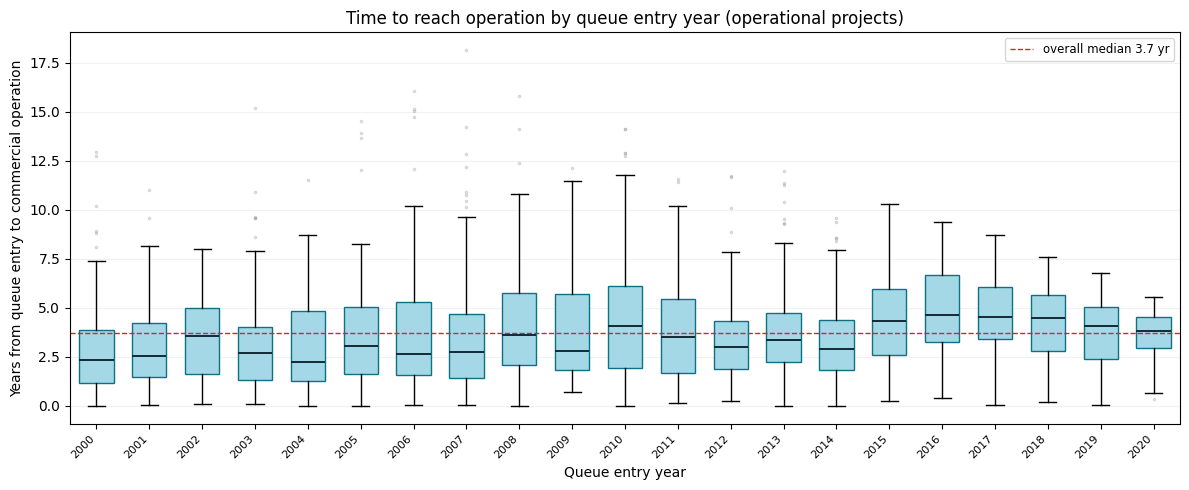


Years-to-COD summary (operational, q_year 2000–2020):
count    2893.00
mean        3.93
std         2.47
min         0.00
10%         1.05
50%         3.69
90%         7.07
max        18.15


In [7]:
op = queue[(queue['q_status'] == 'operational')
           & queue['on_date'].notna() & queue['q_date'].notna()].copy()
op['years_to_cod'] = (op['on_date'] - op['q_date']).dt.days / 365.25
n_bad = (op['years_to_cod'] < 0).sum()
op = op[op['years_to_cod'] >= 0]            # drop on_date-before-q_date errors
op['q_year'] = op['q_year'].astype(int)
print(f'operational projects with a build-out time: {len(op):,} '
      f'(dropped {n_bad} with on_date before q_date)')

years = [y for y in range(2000, 2021) if (op['q_year'] == y).sum() >= 20]
data = [op.loc[op['q_year'] == y, 'years_to_cod'].to_numpy() for y in years]

fig, ax = plt.subplots(figsize=(12, 5))
bp = ax.boxplot(data, positions=years, widths=0.65, patch_artist=True,
                medianprops=dict(color='#102a36', lw=1.4),
                flierprops=dict(marker='.', markersize=3, alpha=0.35, mec='#888'))
for box in bp['boxes']:
    box.set(facecolor='#a5d8e6', edgecolor='#0b7285')
overall = op.loc[op['q_year'].between(2000, 2020), 'years_to_cod'].median()
ax.axhline(overall, color='#c92a2a', ls='--', lw=1,
           label=f'overall median {overall:.1f} yr')
ax.set_xlabel('Queue entry year')
ax.set_ylabel('Years from queue entry to commercial operation')
ax.set_title('Time to reach operation by queue entry year (operational projects)')
ax.set_xticks(years); ax.set_xticklabels(years, rotation=45, ha='right', fontsize=8)
ax.grid(axis='y', color='#eef2f5', lw=0.8); ax.set_axisbelow(True)
ax.legend(fontsize=8.5, loc='upper right')
plt.tight_layout(); plt.show()

print('\nYears-to-COD summary (operational, q_year 2000\u20132020):')
print(op.loc[op['q_year'].between(2000, 2020), 'years_to_cod']
        .describe(percentiles=[.1, .5, .9]).round(2).to_string())


### Takeaway
Median build-out is **~3.5 years** and fairly stable across cohorts, with a long
upper tail (90th percentile ~8 years) — consistent with the ~3.5-yr median the
methodology cites for why recent cohorts are still censored. The dip in the latest
in-window years reflects that censoring (slow builders haven't finished), not
genuinely faster projects.